# **Mental Health in Tech: An EDA of Workplace Attitudes and Treatment Seeking**



##### **Project Type** : EDA
##### **Contribution** : Individual
##### **Name** : Vemula Sai Srikar

# **Project Summary -**

This project digs into the 2014 OSMI Mental Health in Tech survey, about 1259 responses from
people working in tech, covering everything from demographics to workplace policy to how they
personally feel about mental health at work. What I wanted to figure out is pretty simple to ask
and harder to answer: who ends up seeking treatment, and how much does the employer actually have
to do with that.

The raw file needed some real cleanup first. Age had a handful of nonsense entries, negative
numbers and one row with 99999999999, so those got treated as missing and filled with the median.
Gender was messier, 49 different spellings and phrasings for what really boiled down to three
groups, so I collapsed it into Male, Female, and Other. A few columns just were not worth keeping,
comments was 87 percent empty and Timestamp and state did not add much either. One thing I was
careful not to do was blindly fill work_interfere, since that question was only shown to people who
already said they have a condition. Missing there means something real, so it got its own category
instead of being imputed away.

Once the data was in decent shape, I worked through it in stages. First just describing who took
the survey, age, gender, country, company size, then getting into the actual question of what
predicts treatment. Family history and whether the condition gets in the way of work turned out to
matter a lot. Employer policy shows up too, though more subtly, mostly around whether people
actually know what is available to them rather than whether it exists on paper.

That last point ended up being the throughline for the whole analysis. People who were not sure
about their benefits or care options looked a lot more like people with none at all than like
people who had a clear answer. Employers cannot do much about someone's family history, but they
can absolutely fix whether employees know what support exists, and that alone seems to track with
more people getting help.

# **GitHub Link -**

https://github.com/sri-git-prog/mental-health-in-tech-eda

# **Problem Statement**


Talking about mental health at work is still hard, even in an industry that likes to think of
itself as progressive. A lot of tech employees genuinely do not know what their company offers, are
not sure it is safe to bring up a condition, or have no idea how leave actually works for something
like this. This project uses the 2014 OSMI survey to look at who ends up seeking treatment and try
to pin down which of these workplace factors are actually associated with that decision, as opposed
to just being assumed to matter.

#### **Define Your Business Objective?**

The point of this analysis is to give tech employers something to act on, not just a set of
interesting charts. Concretely, that means figuring out which factors, whether personal or something
the company controls, line up most closely with an employee actually getting treatment, so HR and
leadership are not guessing at what to prioritize.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('survey.csv')

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1259
Number of columns: 27


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
comments,1095,86.97
state,515,40.91
work_interfere,264,20.97
self_employed,18,1.43


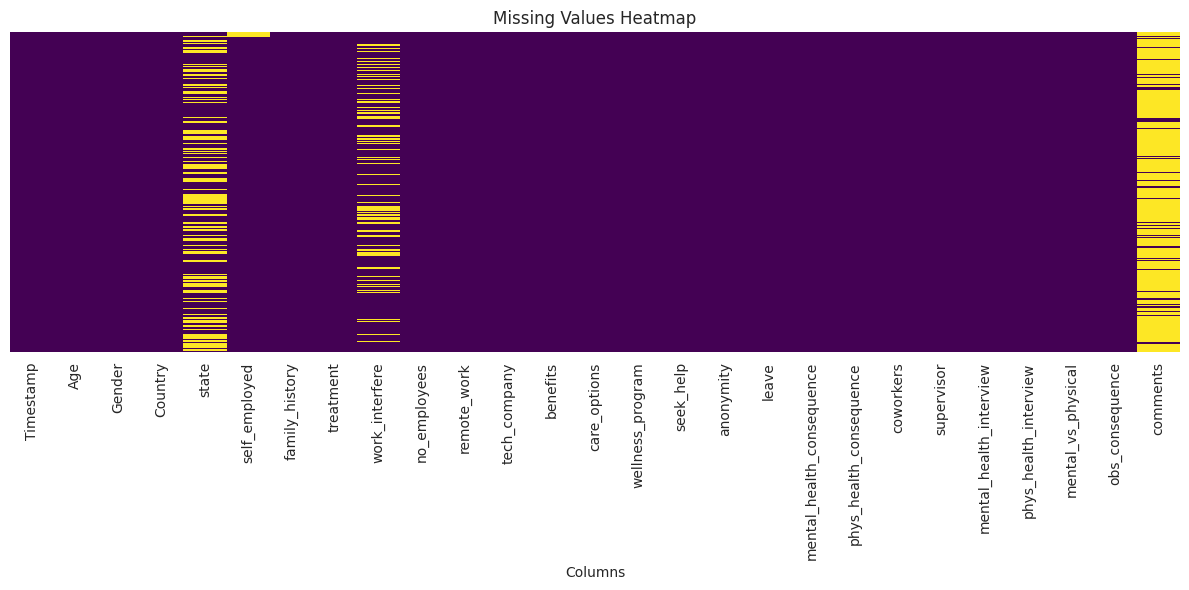

In [8]:
# Visualizing the missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

This is the 2014 OSMI (Open Sourcing Mental Illness) survey on mental health attitudes in the
tech workplace. 1259 rows, 27 columns, mostly categorical (Yes/No/Don't know type answers), with
Age as basically the only real numeric column and Timestamp recording when each response came in.

A few things stood out while checking data quality:
- No exact duplicate rows, so that's one less thing to worry about.
- state is missing for 515 rows, about 41%, mostly because it only makes sense for respondents
  based in the US to begin with.
- self_employed is missing for 18 rows, work_interfere for 264. The work_interfere gap actually
  makes sense once you realize that question only gets asked if someone reported having a
  condition in the first place, so it's not random missingness.
- comments is empty for 1095 rows, about 87%, and it's free form text anyway, so it's not going
  to help with structured analysis.
- Age has some entries that are just wrong, negative numbers and one absurd value like
  99999999999, and those need fixing before anything else can be trusted.
- Gender is a free form field with dozens of different spellings for what amounts to the same
  handful of categories, so that needs cleaning up too before it's usable.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns.tolist()

['Timestamp',
 'Age',
 'Gender',
 'Country',
 'state',
 'self_employed',
 'family_history',
 'treatment',
 'work_interfere',
 'no_employees',
 'remote_work',
 'tech_company',
 'benefits',
 'care_options',
 'wellness_program',
 'seek_help',
 'anonymity',
 'leave',
 'mental_health_consequence',
 'phys_health_consequence',
 'coworkers',
 'supervisor',
 'mental_health_interview',
 'phys_health_interview',
 'mental_vs_physical',
 'obs_consequence',
 'comments']

In [10]:
# Dataset Describe
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1259,1246,2014-08-27 12:31:41,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1259.0,NaN,NaN,NaN,79428148.311358,2818299442.981968,-1726.0,27.0,31.0,36.0,99999999999.0
Gender,1259,49,Male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1259,48,United States,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,744,45,CA,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1241,2,No,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1259,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1259,2,Yes,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,995,4,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1259,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

- **Timestamp**: when the response was submitted.
- **Age**: respondent's age, has some invalid outliers that need cleaning.
- **Gender**: respondent's gender, entered as free text so it needs standardizing.
- **Country / state**: where the respondent is located, state is only filled in for US respondents.
- **self_employed**: whether the respondent is self employed.
- **family_history**: whether there's a family history of mental illness.
- **treatment**: whether the respondent has actually sought treatment, this is the main variable
  the whole analysis is built around.
- **work_interfere**: whether the condition interferes with work, only answered by people who
  have one.
- **no_employees**: how big the respondent's company is.
- **remote_work**: whether the respondent works remotely at least half the time.
- **tech_company**: whether the employer is mainly a tech company.
- **benefits / care_options / wellness_program / seek_help / anonymity / leave**: what mental
  health support the employer offers and how accessible or protected it actually feels.
- **mental_health_consequence / phys_health_consequence**: whether bringing this up at work is
  seen as risky.
- **coworkers / supervisor**: how comfortable respondents are discussing it with coworkers or
  their supervisor.
- **mental_health_interview / phys_health_interview**: whether they'd bring it up in a job
  interview.
- **mental_vs_physical**: whether the employer treats mental health as seriously as physical
  health.
- **obs_consequence**: whether the respondent has seen coworkers face negative consequences for
  their condition.
- **comments**: free text extras, mostly blank, dropped for the analysis.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Timestamp: 1246 unique values
Age: 53 unique values
Gender: 49 unique values
Country: 48 unique values
state: 45 unique values
self_employed: 2 unique values
family_history: 2 unique values
treatment: 2 unique values
work_interfere: 4 unique values
no_employees: 6 unique values
remote_work: 2 unique values
tech_company: 2 unique values
benefits: 3 unique values
care_options: 3 unique values
wellness_program: 3 unique values
seek_help: 3 unique values
anonymity: 3 unique values
leave: 5 unique values
mental_health_consequence: 3 unique values
phys_health_consequence: 3 unique values
coworkers: 3 unique values
supervisor: 3 unique values
mental_health_interview: 3 unique values
phys_health_interview: 3 unique values
mental_vs_physical: 3 unique values
obs_consequence: 2 unique values
comments: 160 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# 1. Drop columns not useful for structured EDA
df_clean = df.drop(columns=['comments', 'Timestamp', 'state'])

# 2. Clean Age: keep only realistic working-age values, treat the rest as missing
df_clean['Age'] = df_clean['Age'].apply(lambda x: x if 18 <= x <= 75 else np.nan)
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Age'] = df_clean['Age'].astype(int)

# 3. Standardize Gender into Male / Female / Other
def clean_gender(g):
    g = str(g).strip().lower()
    male_terms = ['male', 'm', 'man', 'cis male', 'cis man', 'mal', 'male-ish', 'maile',
                  'make', 'mail', 'malr', 'msle', 'guy (-ish) ^_^', 'male (cis)',
                  'cis-female/femme'.split('/')[0], 'ostensibly male, unsure what that really means']
    female_terms = ['female', 'f', 'woman', 'cis female', 'cis-female/femme', 'femake',
                     'female (cis)', 'female (trans)', 'femail', 'woman ']
    if g in male_terms or g.startswith('m'):
        return 'Male'
    elif g in female_terms or g.startswith('f') or g == 'woman':
        return 'Female'
    else:
        return 'Other'

df_clean['Gender'] = df['Gender'].apply(clean_gender)

# 4. Handle remaining missing values
df_clean['self_employed'] = df_clean['self_employed'].fillna('No')
# work_interfere is only answered by people with a mental health condition;
# missing genuinely means "Not applicable", so label it explicitly
df_clean['work_interfere'] = df_clean['work_interfere'].fillna('Not applicable')

# 5. Standardize Country text
df_clean['Country'] = df_clean['Country'].str.strip()

print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum())
df_clean.head()

Missing values after cleaning:
0


,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,United States,No,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,Male,United States,No,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Canada,No,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,United Kingdom,No,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,United States,No,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


### What all manipulations have you done and insights you found?

Here is what changed to get the dataset ready to work with, and why:

- Dropped comments, Timestamp, and state. Comments was free text and 87 percent empty, so there
  was not enough there to use. Timestamp did not matter for what I was studying. State only applies
  to US respondents anyway and Country already covers that ground.
- Fixed Age. Some entries were obviously wrong, negative numbers and one absurd value in the
  billions, so I treated those as missing and filled them with the median age instead of letting a
  handful of typos skew the whole distribution.
- Cleaned up Gender. The raw column had 49 different spellings of basically three categories, things
  like M, male, Cis Male, Woman, all meaning roughly the same thing. I mapped everything down to
  Male, Female, and Other so it could actually be grouped and charted.
- Left self_employed missing values as No, since only 18 rows were affected and No was already the
  majority answer.
- Kept work_interfere missing values as their own category, labeled Not applicable, rather than
  filling them in. That question only gets asked if someone already said they have a condition, so
  the missingness itself is telling you something, not just noise to patch over.
- Trimmed whitespace in Country so the same country was not accidentally split into two categories
  because of a stray space.

After all that, df_clean has zero missing values and is ready for the charts.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

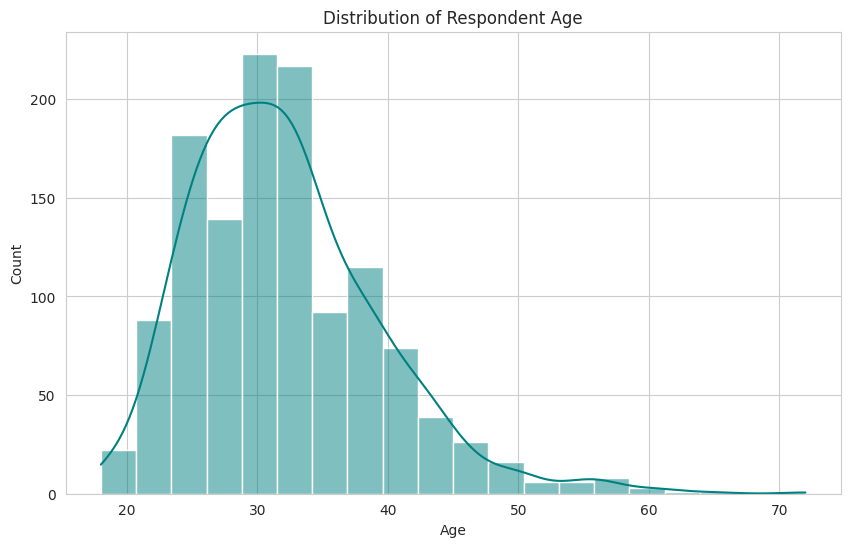

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Age'], bins=20, kde=True, color='teal')
plt.title('Distribution of Respondent Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram made the most sense here since Age is just one numeric column and I wanted to see its shape, where it clusters, whether it is skewed, before doing anything else with it.

##### 2. What is/are the insight(s) found from the chart?

Respondents mostly fall between their late twenties and mid thirties, then it drops off pretty fast after 45. So this is a young workforce, which tracks with what you would expect from tech.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It does. If the workforce skews this young, mental health programs probably land better if they are built around early and mid career pressures, burnout, career anxiety, rather than anything aimed at an older workforce.

#### Chart - 2

/tmp/ipykernel_90/406151492.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Gender', order=order, palette='viridis')


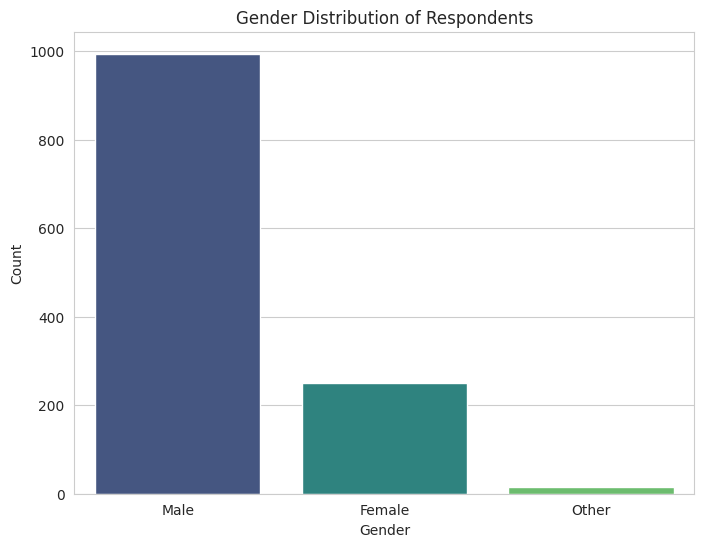

In [14]:
# Chart - 2 visualization code
plt.figure(figsize=(8, 6))
order = df_clean['Gender'].value_counts().index
sns.countplot(data=df_clean, x='Gender', order=order, palette='viridis')
plt.title('Gender Distribution of Respondents')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

With Gender collapsed down to three groups, a count plot was the simplest way to see the split at a glance.

##### 2. What is/are the insight(s) found from the chart?

Men make up the clear majority of respondents, women are a solid chunk too, and Other is a small group.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Sort of, mostly as a caution rather than a finding. The imbalance means anything I say later about gender differences in treatment should be read with the sample size issue in mind, especially for the Other group.

#### Chart - 3

/tmp/ipykernel_90/3001262131.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='treatment', palette='Set2')


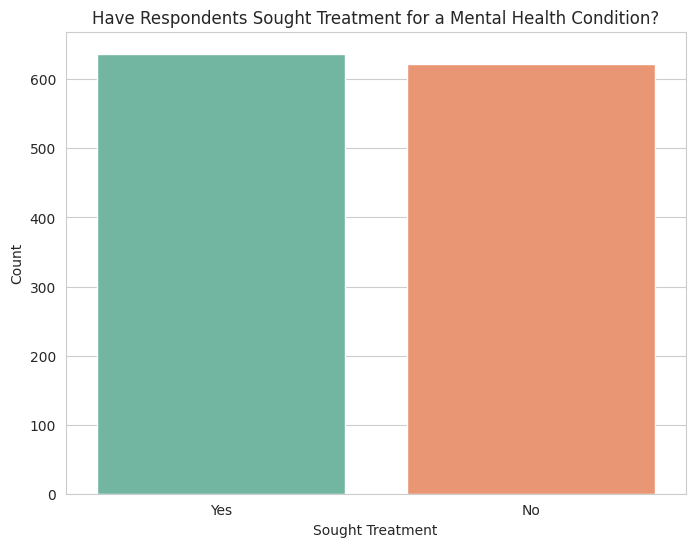

In [15]:
# Chart - 3 visualization code
plt.figure(figsize=(8, 6))
sns.countplot(data=df_clean, x='treatment', palette='Set2')
plt.title('Have Respondents Sought Treatment for a Mental Health Condition?')
plt.xlabel('Sought Treatment')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

Treatment is the variable everything else in this project is built around, so before comparing it to anything I just wanted to see the baseline split.

##### 2. What is/are the insight(s) found from the chart?

It is close to even, with slightly more people having sought treatment than not. So there is real variation here to actually explain, which is good news for the rest of the analysis.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yeah, that even split is basically what makes the rest of this worth doing. If almost everyone answered the same way there would not be much to dig into.

#### Chart - 4

/tmp/ipykernel_90/3443710304.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='mako')


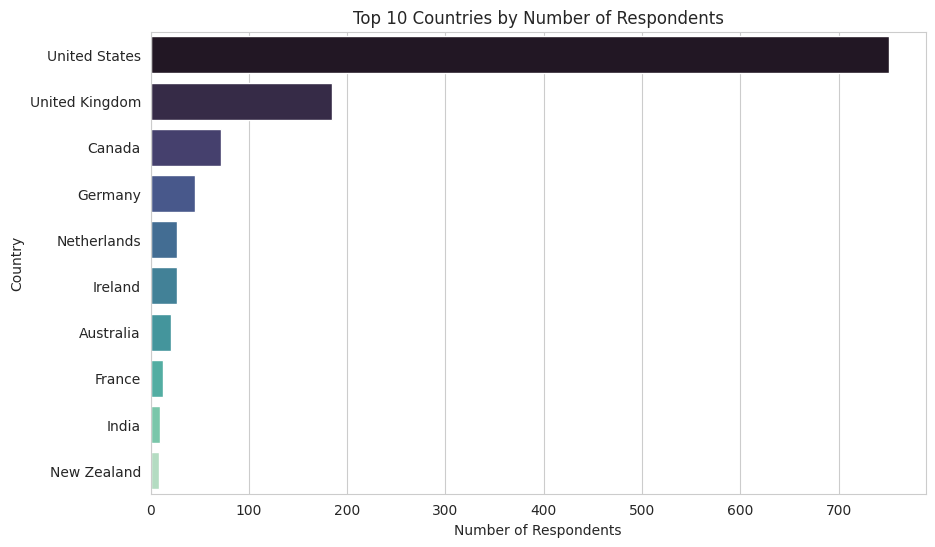

In [16]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 6))
top_countries = df_clean['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='mako')
plt.title('Top 10 Countries by Number of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')
plt.show()

##### 1. Why did you pick the specific chart?

Country has a long tail of low count values, so a horizontal bar chart made it easier to read the top ones than trying to cram everything into a count plot.

##### 2. What is/are the insight(s) found from the chart?

The US dominates the responses by a wide margin, with the UK and Canada a distant second and third. Most other countries only show up a handful of times.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

With a caveat, yes. Whatever conclusions come out of this data are mostly telling you about US workplace norms, and to a lesser degree UK and Canada. I would not assume this generalizes to, say, tech companies in India or Germany without more balanced data from those places.

#### Chart - 5

/tmp/ipykernel_90/3753029469.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='no_employees', order=order, palette='crest')


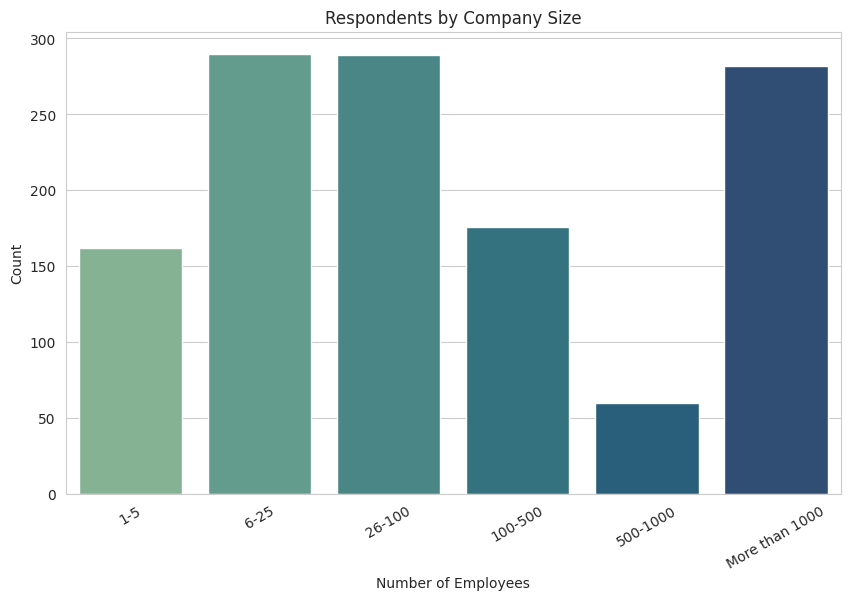

In [17]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 6))
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
sns.countplot(data=df_clean, x='no_employees', order=order, palette='crest')
plt.title('Respondents by Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

##### 1. Why did you pick the specific chart?

Company size is ordinal, so I ordered the bars from smallest to largest instead of leaving them in whatever order pandas defaulted to. Makes the pattern across sizes much easier to follow.

##### 2. What is/are the insight(s) found from the chart?

Respondents are spread out pretty evenly across sizes, with a bit of a bump at both ends, very small companies and companies over a thousand people.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It does, mainly because it confirms the dataset is not just one type of company. Whatever gets said later about company size and treatment is not coming from a sample of only startups or only big enterprises.

#### Chart - 6

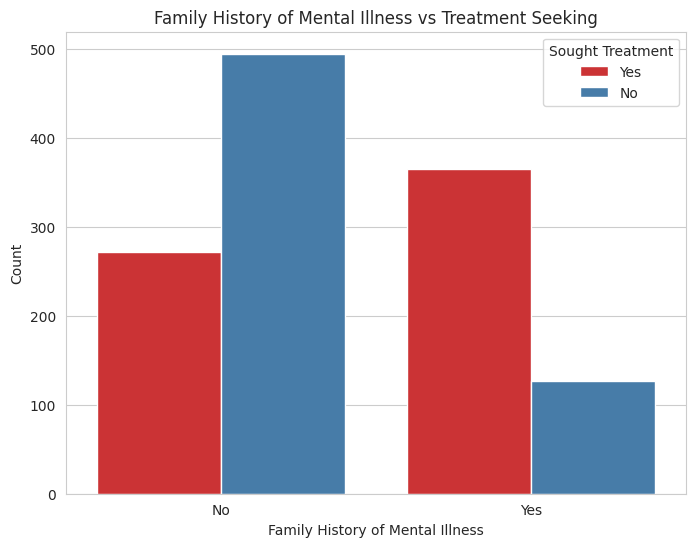

In [18]:
# Chart - 6 visualization code
plt.figure(figsize=(8, 6))
sns.countplot(data=df_clean, x='family_history', hue='treatment', palette='Set1')
plt.title('Family History of Mental Illness vs Treatment Seeking')
plt.xlabel('Family History of Mental Illness')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.show()

##### 1. Why did you pick the specific chart?

Both variables here are binary, so a grouped count plot was the obvious way to see how treatment splits across the two family history groups.

##### 2. What is/are the insight(s) found from the chart?

People with a family history of mental illness are a lot more likely to have sought treatment. Without that history, most people have not sought treatment at all.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This was the strongest single pattern in the whole dataset. Obviously nobody can change their own family history, but it is a useful thing for HR to keep in mind, differences in treatment rates are not automatically a sign of a policy failure, sometimes it is just this.

#### Chart - 7

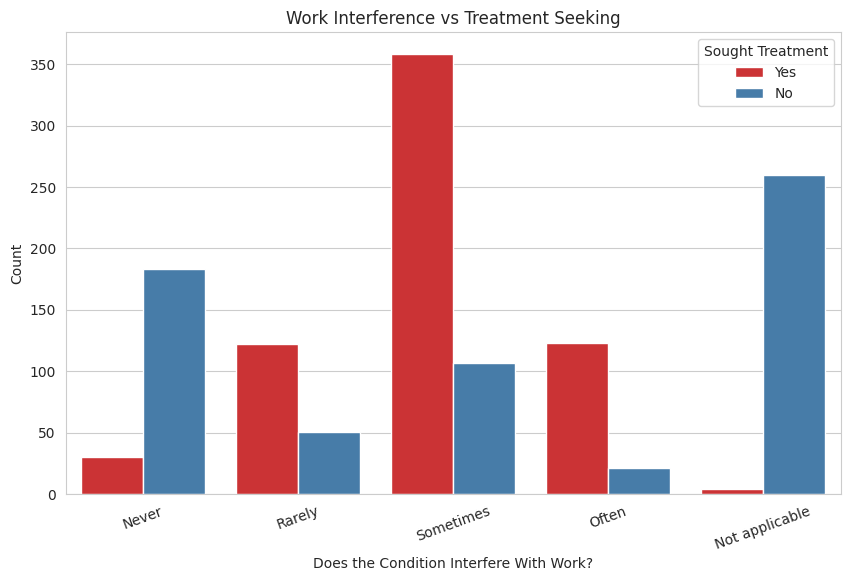

In [19]:
# Chart - 7 visualization code
plt.figure(figsize=(10, 6))
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Not applicable']
sns.countplot(data=df_clean, x='work_interfere', hue='treatment', order=order, palette='Set1')
plt.title('Work Interference vs Treatment Seeking')
plt.xlabel('Does the Condition Interfere With Work?')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.xticks(rotation=20)
plt.show()

##### 1. Why did you pick the specific chart?

Work interference has a natural order, from Never up to Often, so ordering it that way lets you actually see the trend build instead of scattering it across the chart.

##### 2. What is/are the insight(s) found from the chart?

Treatment goes up sharply as interference gets worse. Almost everyone who says their condition interferes with work Often is in treatment, and almost everyone in Not applicable, meaning no condition, is not, which is basically what you would expect.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Definitely. This says severity is doing a lot of the work in predicting treatment. If I were designing an intervention I would target the Sometimes group specifically, since that is the one place the split is not already settled one way or the other.

#### Chart - 8

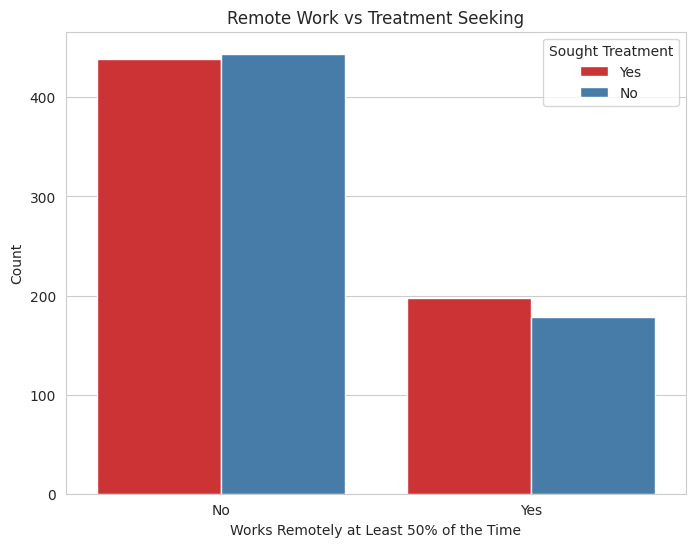

In [20]:
# Chart - 8 visualization code
plt.figure(figsize=(8, 6))
sns.countplot(data=df_clean, x='remote_work', hue='treatment', palette='Set1')
plt.title('Remote Work vs Treatment Seeking')
plt.xlabel('Works Remotely at Least 50% of the Time')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.show()

##### 1. Why did you pick the specific chart?

Remote work and treatment are both binary, so the same grouped count plot format as the family history chart made sense here too.

##### 2. What is/are the insight(s) found from the chart?

The treatment rates for remote and non remote workers look basically the same. Working remotely does not seem to move the needle much either way.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It is still useful, just as a negative result. Employers should not assume remote work policy alone fixes or worsens mental health outcomes, so it is probably not where the effort should go.

#### Chart - 9

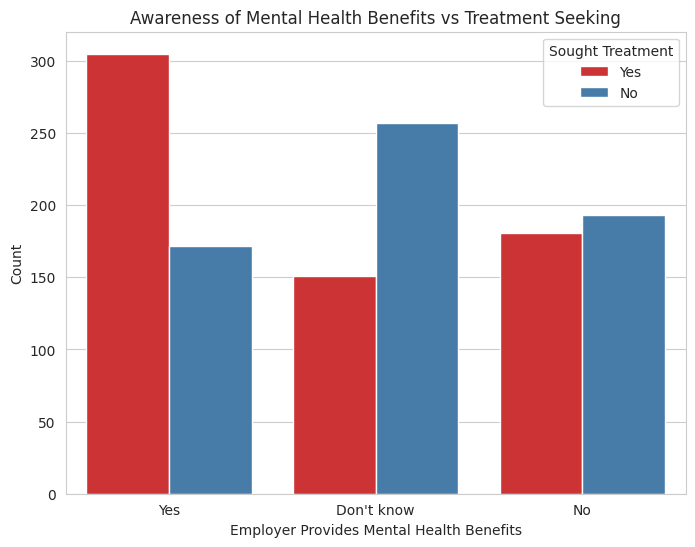

In [21]:
# Chart - 9 visualization code
plt.figure(figsize=(8, 6))
sns.countplot(data=df_clean, x='benefits', hue='treatment', order=['Yes', "Don't know", 'No'], palette='Set1')
plt.title('Awareness of Mental Health Benefits vs Treatment Seeking')
plt.xlabel('Employer Provides Mental Health Benefits')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.show()

##### 1. Why did you pick the specific chart?

This one goes straight at an employer controlled variable, so I ordered it from Yes to No to make the gradient obvious.

##### 2. What is/are the insight(s) found from the chart?

People who know their employer offers mental health benefits have a noticeably higher treatment rate. What stood out to me is that the Don't know group looks a lot closer to No than to Yes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is probably the most actionable finding in the whole project. If Don't know behaves like No, then the fix is not necessarily adding new benefits, it is making sure people actually know what already exists.

#### Chart - 10

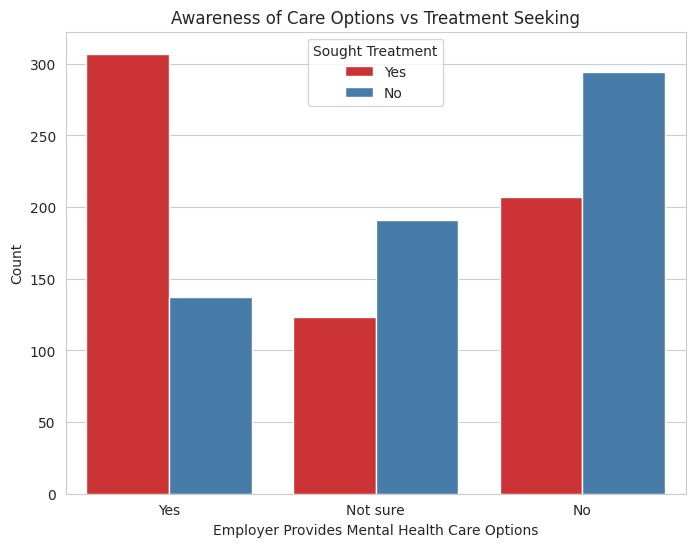

In [22]:
# Chart - 10 visualization code
plt.figure(figsize=(8, 6))
sns.countplot(data=df_clean, x='care_options', hue='treatment', order=['Yes', 'Not sure', 'No'], palette='Set1')
plt.title('Awareness of Care Options vs Treatment Seeking')
plt.xlabel('Employer Provides Mental Health Care Options')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.show()

##### 1. Why did you pick the specific chart?

Care options is basically the same kind of variable as benefits, so I kept the chart format consistent to make the comparison easy.

##### 2. What is/are the insight(s) found from the chart?

Same story as benefits. Knowing your care options tracks with higher treatment, and Not sure again looks closer to No than to Yes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, and honestly this reinforces the benefits chart more than it adds something new. Together they make a pretty strong case that clarity, not just the existence of a program, is what matters.

#### Chart - 11

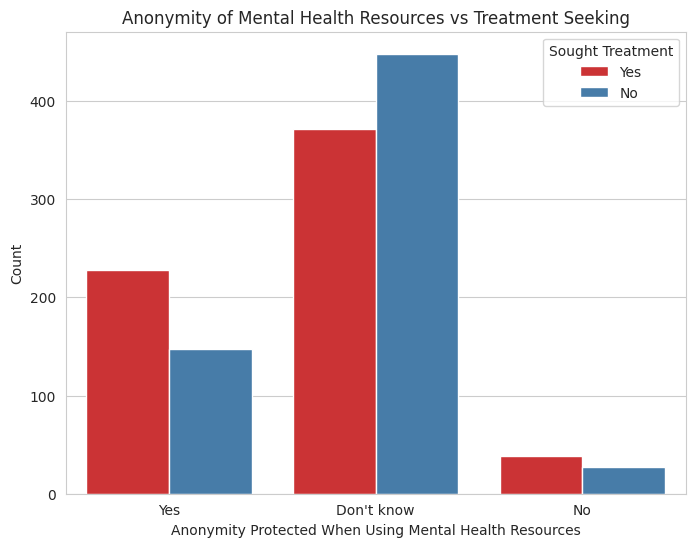

In [23]:
# Chart - 11 visualization code
plt.figure(figsize=(8, 6))
sns.countplot(data=df_clean, x='anonymity', hue='treatment', order=['Yes', "Don't know", 'No'], palette='Set1')
plt.title('Anonymity of Mental Health Resources vs Treatment Seeking')
plt.xlabel('Anonymity Protected When Using Mental Health Resources')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.show()

##### 1. Why did you pick the specific chart?

Anonymity concerns come up a lot as a reason people avoid seeking help, so I wanted to check whether that shows up in this data.

##### 2. What is/are the insight(s) found from the chart?

People who know their anonymity is protected have a higher treatment rate than the Don't know group. The No group is small enough that I would not read too much into its exact shape.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it supports making confidentiality clear and explicit rather than leaving it as something people have to assume. That seems to correlate with more people actually using the resources.

#### Chart - 12

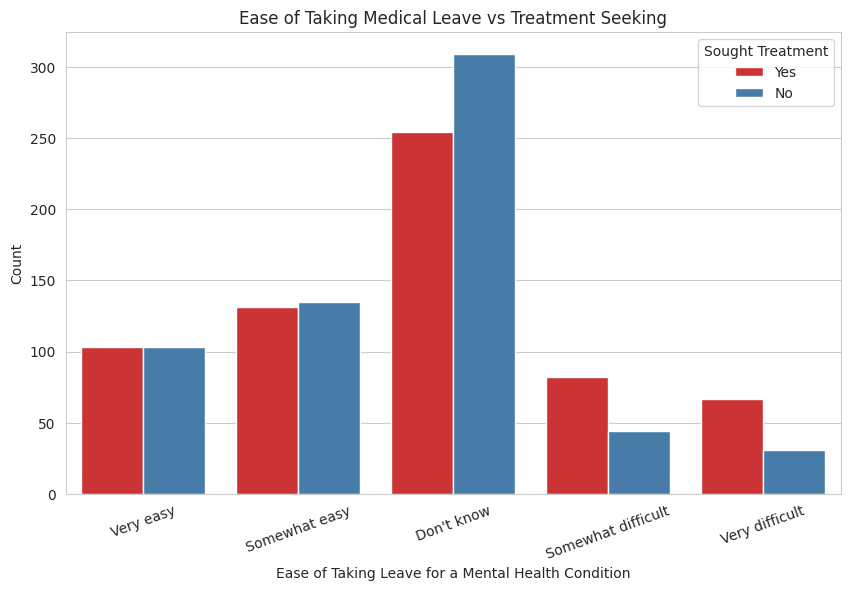

In [24]:
# Chart - 12 visualization code
plt.figure(figsize=(10, 6))
order = ['Very easy', 'Somewhat easy', "Don't know", 'Somewhat difficult', 'Very difficult']
sns.countplot(data=df_clean, x='leave', hue='treatment', order=order, palette='Set1')
plt.title('Ease of Taking Medical Leave vs Treatment Seeking')
plt.xlabel('Ease of Taking Leave for a Mental Health Condition')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.xticks(rotation=20)
plt.show()

##### 1. Why did you pick the specific chart?

Leave is ordinal too, Very easy down to Very difficult, so I ordered it the same way as work interference to make the trend readable.

##### 2. What is/are the insight(s) found from the chart?

People who find leave Very difficult, or who are not sure how it works, have somewhat lower treatment rates than people who find it easy. The relationship is there but it is not as sharp as family history or interference.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yeah, and this one feels like a relatively cheap fix. Making the leave process clear and easy to understand is a lower effort change than redesigning benefits, and it still seems to move things in the right direction.

#### Chart - 13

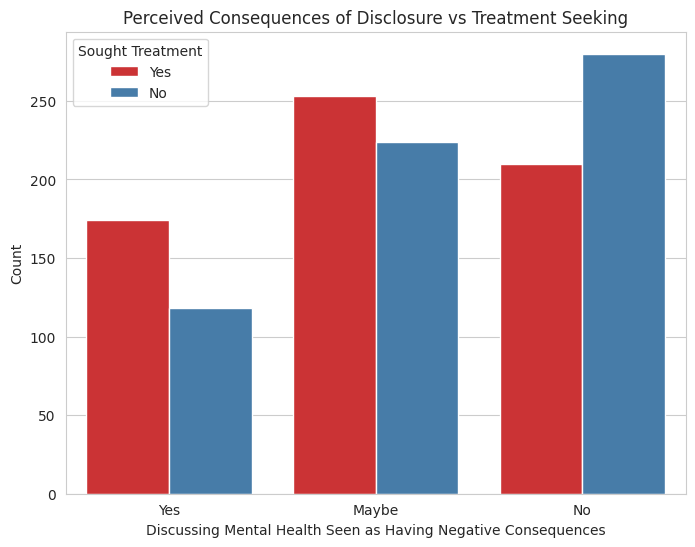

In [25]:
# Chart - 13 visualization code
plt.figure(figsize=(8, 6))
sns.countplot(data=df_clean, x='mental_health_consequence', hue='treatment', order=['Yes', 'Maybe', 'No'], palette='Set1')
plt.title('Perceived Consequences of Disclosure vs Treatment Seeking')
plt.xlabel('Discussing Mental Health Seen as Having Negative Consequences')
plt.ylabel('Count')
plt.legend(title='Sought Treatment')
plt.show()

##### 1. Why did you pick the specific chart?

This chart tests the culture side of things directly, whether people think discussing mental health has consequences, using the same format as the other policy comparisons for consistency.

##### 2. What is/are the insight(s) found from the chart?

People who think disclosure has negative consequences are still fairly likely to have sought treatment. So perceived stigma alone does not seem to hold people back as much as the more concrete factors did.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It is more of a caution than a lever. Reducing stigma still matters for how safe people feel at work, but on its own it does not look like it moves the treatment number as much as clearer communication about benefits and leave does.

#### Chart - 14 - Correlation Heatmap

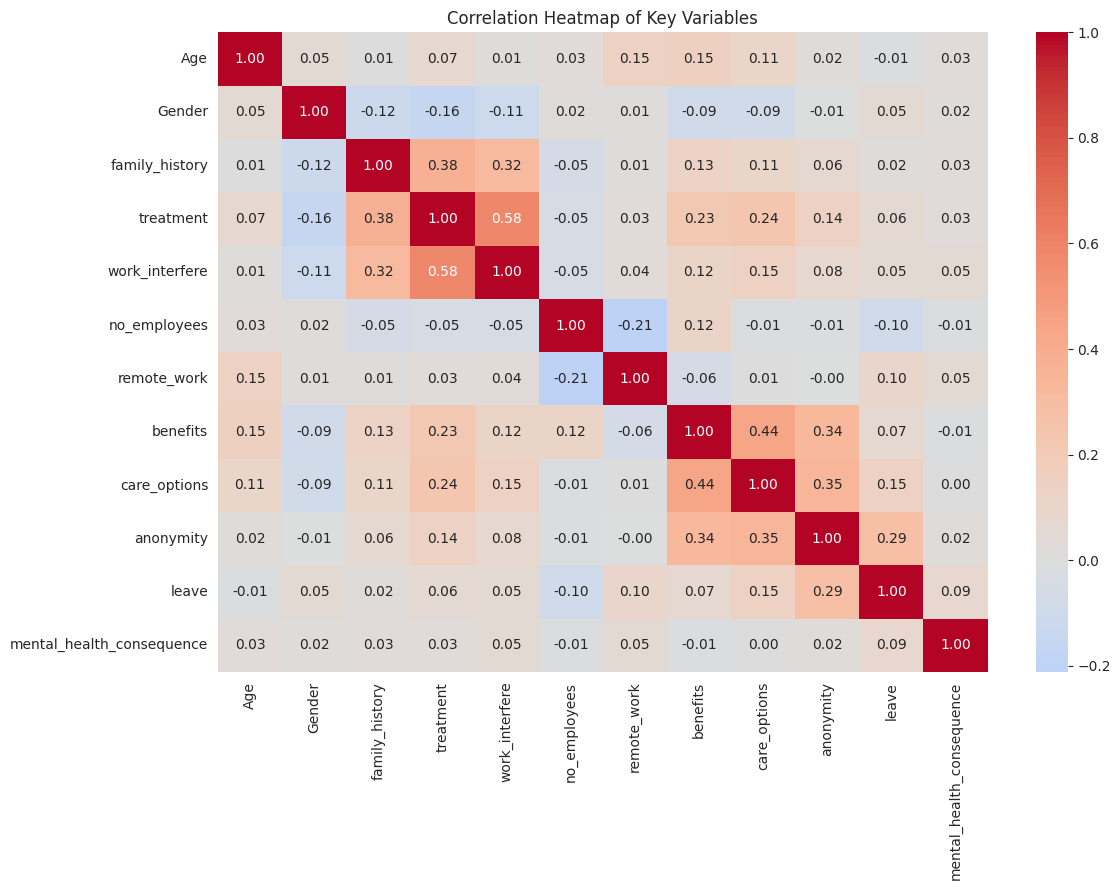

In [26]:
# Correlation Heatmap visualization code
from sklearn.preprocessing import LabelEncoder

# Encode key categorical variables so correlation can be computed alongside Age
corr_cols = ['Age', 'Gender', 'family_history', 'treatment', 'work_interfere',
             'no_employees', 'remote_work', 'benefits', 'care_options',
             'anonymity', 'leave', 'mental_health_consequence']
df_corr = df_clean[corr_cols].copy()

le = LabelEncoder()
for col in df_corr.columns:
    if col != 'Age':
        df_corr[col] = le.fit_transform(df_corr[col].astype(str))

plt.figure(figsize=(12, 9))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Key Variables')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap felt like a good way to sanity check everything at once, see if there is a relationship between two variables that never came up in the individual chart comparisons.

##### 2. What is/are the insight(s) found from the chart?

Treatment correlates most with work_interfere and family_history, which lines up with everything found earlier. The employer side variables, benefits, care_options, anonymity, leave, are all weakly but consistently correlated with treatment in the expected direction. None of them alone is as strong as the personal factors, but they are pulling the same way.

#### Chart - 15 - Pair Plot

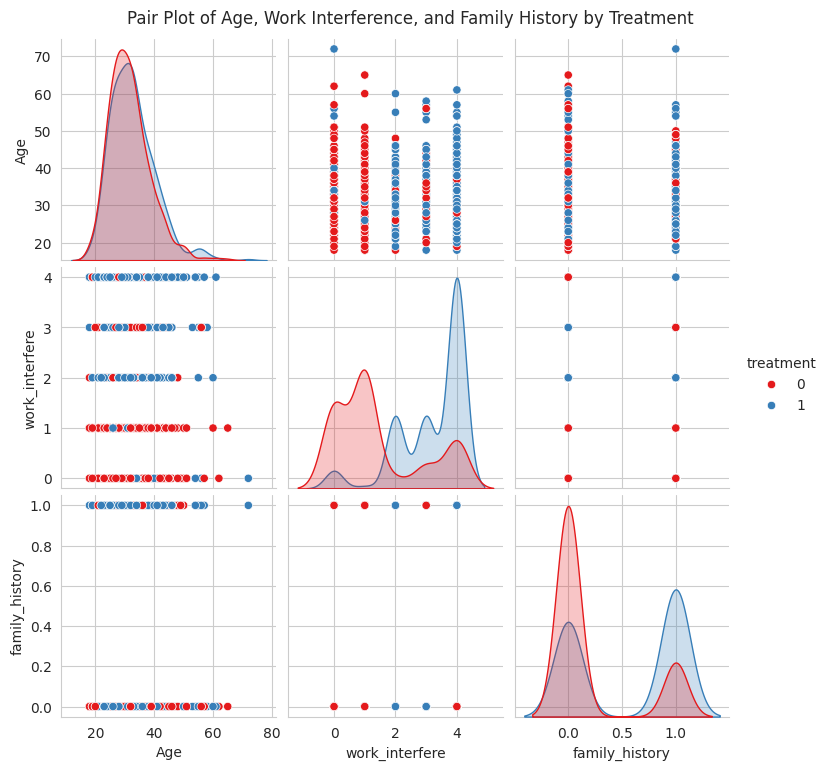

In [27]:
# Pair Plot visualization code
pairplot_df = df_corr[['Age', 'work_interfere', 'family_history', 'treatment']].copy()
sns.pairplot(pairplot_df, hue='treatment', palette='Set1', diag_kind='kde')
plt.suptitle('Pair Plot of Age, Work Interference, and Family History by Treatment', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot seemed like a good closing chart, it shows every pairwise relationship between a small set of variables at once, split by treatment, so it is a decent last check for anything the earlier charts missed.

##### 2. What is/are the insight(s) found from the chart?

The diagonal distributions confirm what showed up earlier, higher work_interfere and family_history both shift toward the treatment group. Nothing in the scatter panels suggested a strong extra interaction with Age, it behaves about the same across both treatment groups.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

A few concrete things come out of this that a tech employer could actually act on.

First, and this is the big one, make benefits and care options impossible to miss. The gap in this
data is not really between having good benefits and not having them, it is between knowing about
them and not knowing. People who answered Don't know or Not sure look almost the same as people
with nothing at all. A clear onboarding message and a yearly reminder would probably close most of
that gap, and it costs almost nothing to do.

Second, make the leave process for mental health as easy to understand as leave for a physical
illness. People who found it confusing or difficult had lower treatment rates than people who found
it straightforward. This is a communication fix more than a policy overhaul, so it should be quick
to roll out.

Third, keep working on stigma and anonymity, but treat it as a longer term culture project rather
than the main lever to pull. Perceived consequences of disclosure did not suppress treatment as
strongly as the clearer, more concrete factors above, so manager training and confidential access to
resources are worth doing, but I would expect the clarity focused changes to move the numbers
faster.

None of this touches family history or symptom severity, which are still the strongest predictors
and completely outside an employer's control. The realistic goal is not changing who develops a
condition in the first place, it is making sure nothing gets in the way between someone who needs
help and the help that is already sitting there for them.

# **Conclusion**

This project set out to figure out what actually separates tech employees who seek treatment
from those who do not, and where an employer could realistically make a difference.

Getting there took a fair amount of cleanup first, fixing broken Age values, collapsing 49 versions
of Gender down to three, and making a judgment call on each column with missing data about whether
to drop it, fill it, or leave the gap as meaningful on its own.

The clearest result is that personal factors, family history and how much a condition interferes
with work, predict treatment better than anything else in the dataset, and neither of those is
something an employer can touch. But among the things a company can control, clarity kept showing
up as the thing that mattered. People who were unsure what their benefits or leave policy actually
covered behaved a lot more like people with no support at all than like people who knew exactly what
was available to them. That is a communication problem, not really a policy gap.

So if a company wants to move its treatment rate, the cheapest and most effective thing it can do is
make its existing benefits, care options, and leave policy unmistakably clear, and pair that with a
longer term push on reducing stigma around bringing any of it up in the first place.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***